# Loading and Visualizing Synthetic Seismic Dataset

This notebook demonstrates how to load and explore the synthetic seismogram dataset created with SeisBench format.

## 1. Import Required Libraries

In [18]:
import seisbench.data as sbd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Load Dataset from Disk

Load the synthetic dataset using SeisBench's `WaveformDataset` class by pointing to the directory containing `metadata.csv` and `waveforms.hdf5`.

In [19]:
# Load the synthetic dataset
dataset = sbd.WaveformDataset('../data', sampling_rate=100)

print(f"Dataset loaded successfully!")
print(f"Number of traces: {len(dataset)}")
print(f"Sampling rate: {dataset.sampling_rate} Hz")

2026-02-17 15:53:31,198 | seisbench | WARNING | Component order not specified, defaulting to 'ZNE'.


Dataset loaded successfully!
Number of traces: 200
Sampling rate: 100 Hz


## 3. Inspect Metadata

The metadata is stored as a pandas DataFrame with information about each trace, including station info, phase picks, and source parameters.

In [20]:
# Display the first few rows of metadata
dataset.metadata.head(15)

,index,trace_name_original,station_network_code,station_code,station_latitude_deg,station_longitude_deg,trace_channel,trace_sampling_rate_hz,trace_npts,trace_start_time,...,source_origin_time,source_type,source_magnitude,source_magnitude_type,source_magnitude_author,trace_snr_db,split,trace_name,trace_chunk,trace_component_order
0,0,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,34.7763,-98.6475,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,9.440418,train,"bucket0$0,:3,:12000",,ZNE
1,1,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,35.3445,-96.9140,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,7.595928,test,"bucket1$0,:3,:12000",,ZNE
2,2,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,35.1338,-100.2064,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,9.397277,test,"bucket1$1,:3,:12000",,ZNE
3,3,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,36.8605,-98.2126,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,8.666194,train,"bucket0$1,:3,:12000",,ZNE
4,4,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,36.8757,-95.9986,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,6.198890,train,"bucket0$2,:3,:12000",,ZNE
5,5,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,35.4138,-98.8108,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,4.165083,train,"bucket0$3,:3,:12000",,ZNE
6,6,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,35.3597,-100.3777,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,4.457988,train,"bucket0$4,:3,:12000",,ZNE
7,7,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,36.6114,-101.4875,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,4.043346,train,"bucket0$5,:3,:12000",,ZNE
8,8,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,35.3687,-100.1148,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,6.573102,dev,"bucket2$0,:3,:12000",,ZNE
9,9,QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...,QD,HX,34.3491,-97.9639,HH,100.0,12000,1970-01-01T00:00:00,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,6.642925,train,"bucket0$6,:3,:12000",,ZNE


In [21]:
# Show available columns
print("Available columns:")
for col in dataset.metadata.columns:
    print(f"  - {col}")

Available columns:
  - index
  - trace_name_original
  - station_network_code
  - station_code
  - station_latitude_deg
  - station_longitude_deg
  - trace_channel
  - trace_sampling_rate_hz
  - trace_npts
  - trace_start_time
  - trace_p_arrival_sample
  - trace_p_status
  - trace_p_weight
  - trace_s_arrival_sample
  - trace_s_status
  - trace_s_weight
  - source_id
  - source_origin_time
  - source_type
  - source_magnitude
  - source_magnitude_type
  - source_magnitude_author
  - trace_snr_db
  - split
  - trace_name
  - trace_chunk
  - trace_component_order


In [22]:
# Display summary statistics
print("Dataset Summary:")
print(f"  Stations: {dataset.metadata['station_code'].nunique()}")
print(f"  Networks: {dataset.metadata['station_network_code'].nunique()}")
print(f"  Traces with P-picks: {dataset.metadata['trace_p_arrival_sample'].notna().sum()}")
print(f"  Traces with S-picks: {dataset.metadata['trace_s_arrival_sample'].notna().sum()}")
print(f"\nSNR Statistics:")
print(f"  Mean: {dataset.metadata['trace_snr_db'].mean():.2f} dB")
print(f"  Range: {dataset.metadata['trace_snr_db'].min():.2f} - {dataset.metadata['trace_snr_db'].max():.2f} dB")

Dataset Summary:
  Stations: 1
  Networks: 1
  Traces with P-picks: 200
  Traces with S-picks: 200

SNR Statistics:
  Mean: 6.35 dB
  Range: 4.01 - 9.99 dB


## 4. Load and Visualize a Single Trace

Get waveforms for a single trace and plot all three components (Z, N, E) with phase picks.

In [23]:
# Select trace index
trace_idx = 0

# Get waveforms (shape: 3 components × n_samples)
waveforms = dataset.get_waveforms(trace_idx)
metadata = dataset.metadata.iloc[trace_idx]

print(f"Waveform shape: {waveforms.shape}")
print(f"Event ID: {metadata['source_id']}")
print(f"Sampling rate: {metadata['trace_sampling_rate_hz']} Hz")
print(f"Number of samples: {metadata['trace_npts']}")

Waveform shape: (3, 12000)
Event ID: SYNTHETIC_001
Sampling rate: 100.0 Hz
Number of samples: 12000


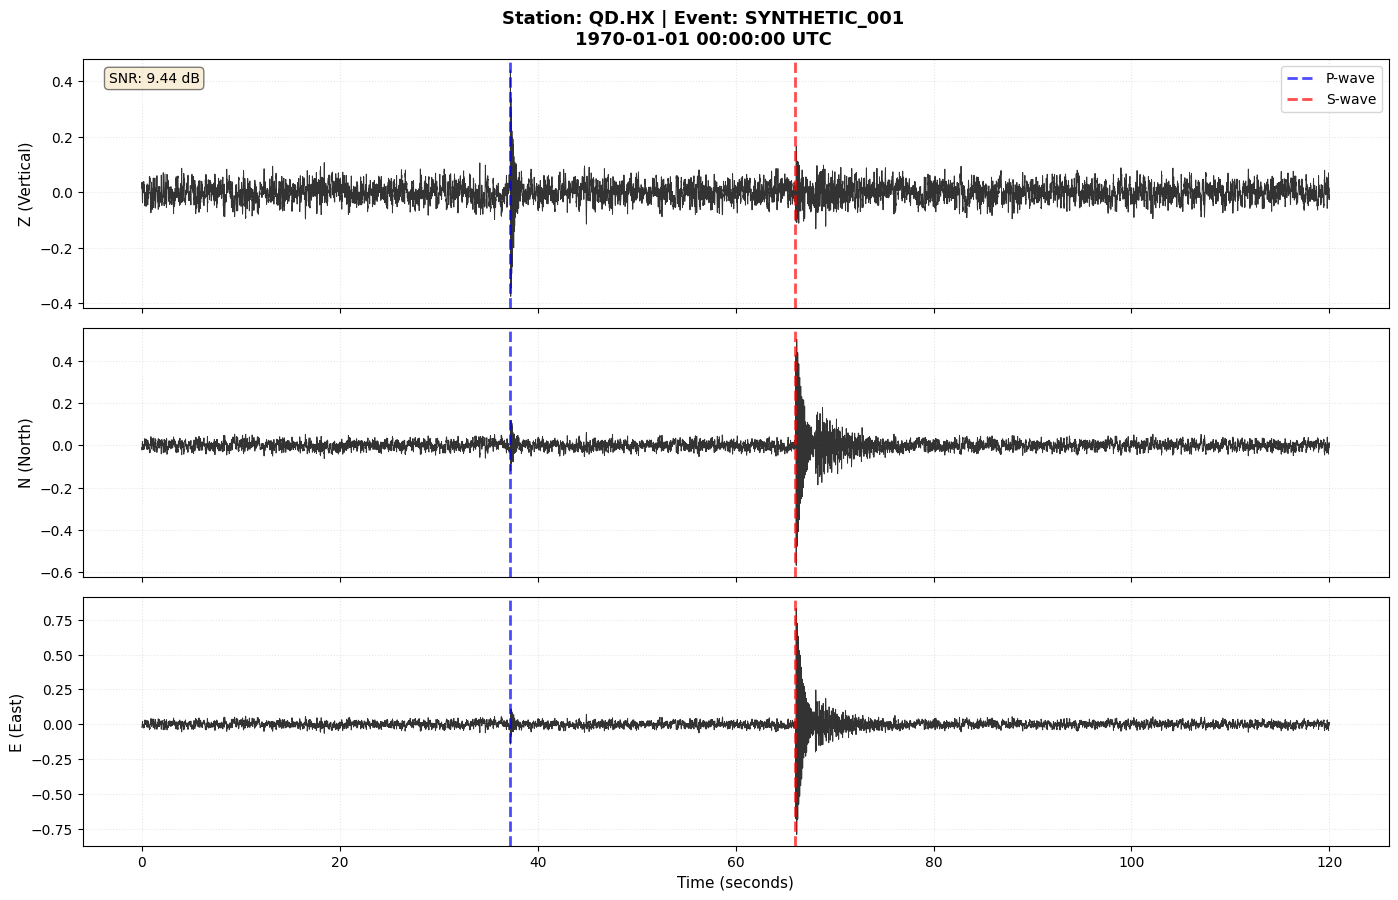


TRACE INFORMATION
Station:        QD.HX
Event ID:       SYNTHETIC_001
Date/Time:      1970-01-01 00:00:00 UTC
Sampling Rate:  100.0 Hz
SNR:            9.44 dB

Phase Arrivals:
  P-wave:       sample 3723 (37.23 s)
  S-wave:       sample 6605 (66.05 s)
  S-P time:     28.82 s


In [24]:
# Extract phase arrival information
p_sample = metadata['trace_p_arrival_sample']
s_sample = metadata['trace_s_arrival_sample']
sampling_rate = metadata['trace_sampling_rate_hz']
snr_db = metadata['trace_snr_db']

# Extract station and timing information
network = metadata['station_network_code']
station = metadata['station_code']
event_id = metadata['source_id']

# Get datetime if available
if 'trace_start_time' in metadata and pd.notna(metadata['trace_start_time']):
    start_time = pd.to_datetime(metadata['trace_start_time'])
    datetime_str = start_time.strftime('%Y-%m-%d %H:%M:%S UTC')
else:
    datetime_str = 'N/A'

# Create time axis
n_samples = waveforms.shape[1]
time_axis = np.arange(n_samples) / sampling_rate

# Plot three components
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
component_names = ['Z (Vertical)', 'N (North)', 'E (East)']
colors = ['black', 'black', 'black']

# Add main title with station info
fig.suptitle(f'Station: {network}.{station} | Event: {event_id}\n{datetime_str}', 
             fontsize=13, fontweight='bold', y=0.995)

for i, (ax, name, color) in enumerate(zip(axes, component_names, colors)):
    # Plot waveform
    ax.plot(time_axis, waveforms[i], color=color, linewidth=0.7, alpha=0.8)
    
    # Mark phase arrivals
    if not np.isnan(p_sample):
        p_time = p_sample / sampling_rate
        ax.axvline(p_time, color='blue', linestyle='--', linewidth=2, label='P-wave', alpha=0.7)
    
    if not np.isnan(s_sample):
        s_time = s_sample / sampling_rate
        ax.axvline(s_time, color='red', linestyle='--', linewidth=2, label='S-wave', alpha=0.7)
    
    # Formatting
    ax.set_ylabel(name, fontsize=11)
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Add SNR info to first subplot
    if i == 0:
        ax.text(0.02, 0.95, f'SNR: {snr_db:.2f} dB', 
                transform=ax.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.5))
        ax.legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

# Print detailed information
print(f"\n{'='*60}")
print(f"TRACE INFORMATION")
print(f"{'='*60}")
print(f"Station:        {network}.{station}")
print(f"Event ID:       {event_id}")
print(f"Date/Time:      {datetime_str}")
print(f"Sampling Rate:  {sampling_rate} Hz")
print(f"SNR:            {snr_db:.2f} dB")
print(f"\nPhase Arrivals:")
print(f"  P-wave:       sample {p_sample:.0f} ({p_sample/sampling_rate:.2f} s)")
print(f"  S-wave:       sample {s_sample:.0f} ({s_sample/sampling_rate:.2f} s)")
print(f"  S-P time:     {(s_sample - p_sample)/sampling_rate:.2f} s")
print(f"{'='*60}")

## 5. Load Multiple Traces

Demonstrate loading multiple traces at once for batch processing.

In [25]:
# Load first 4 traces
trace_indices = [0, 1, 2, 3]
waveforms_batch = dataset.get_waveforms(trace_indices)

print(f"Batch waveform shape: {waveforms_batch.shape}")
print(f"  Dimensions: (n_traces, n_components, n_samples)")
print(f"  {waveforms_batch.shape[0]} traces × {waveforms_batch.shape[1]} components × {waveforms_batch.shape[2]} samples")

Batch waveform shape: (4, 3, 12000)
  Dimensions: (n_traces, n_components, n_samples)
  4 traces × 3 components × 12000 samples


## 6. Plot Overview of Multiple Traces

Visualize multiple traces to see the variety in the dataset.

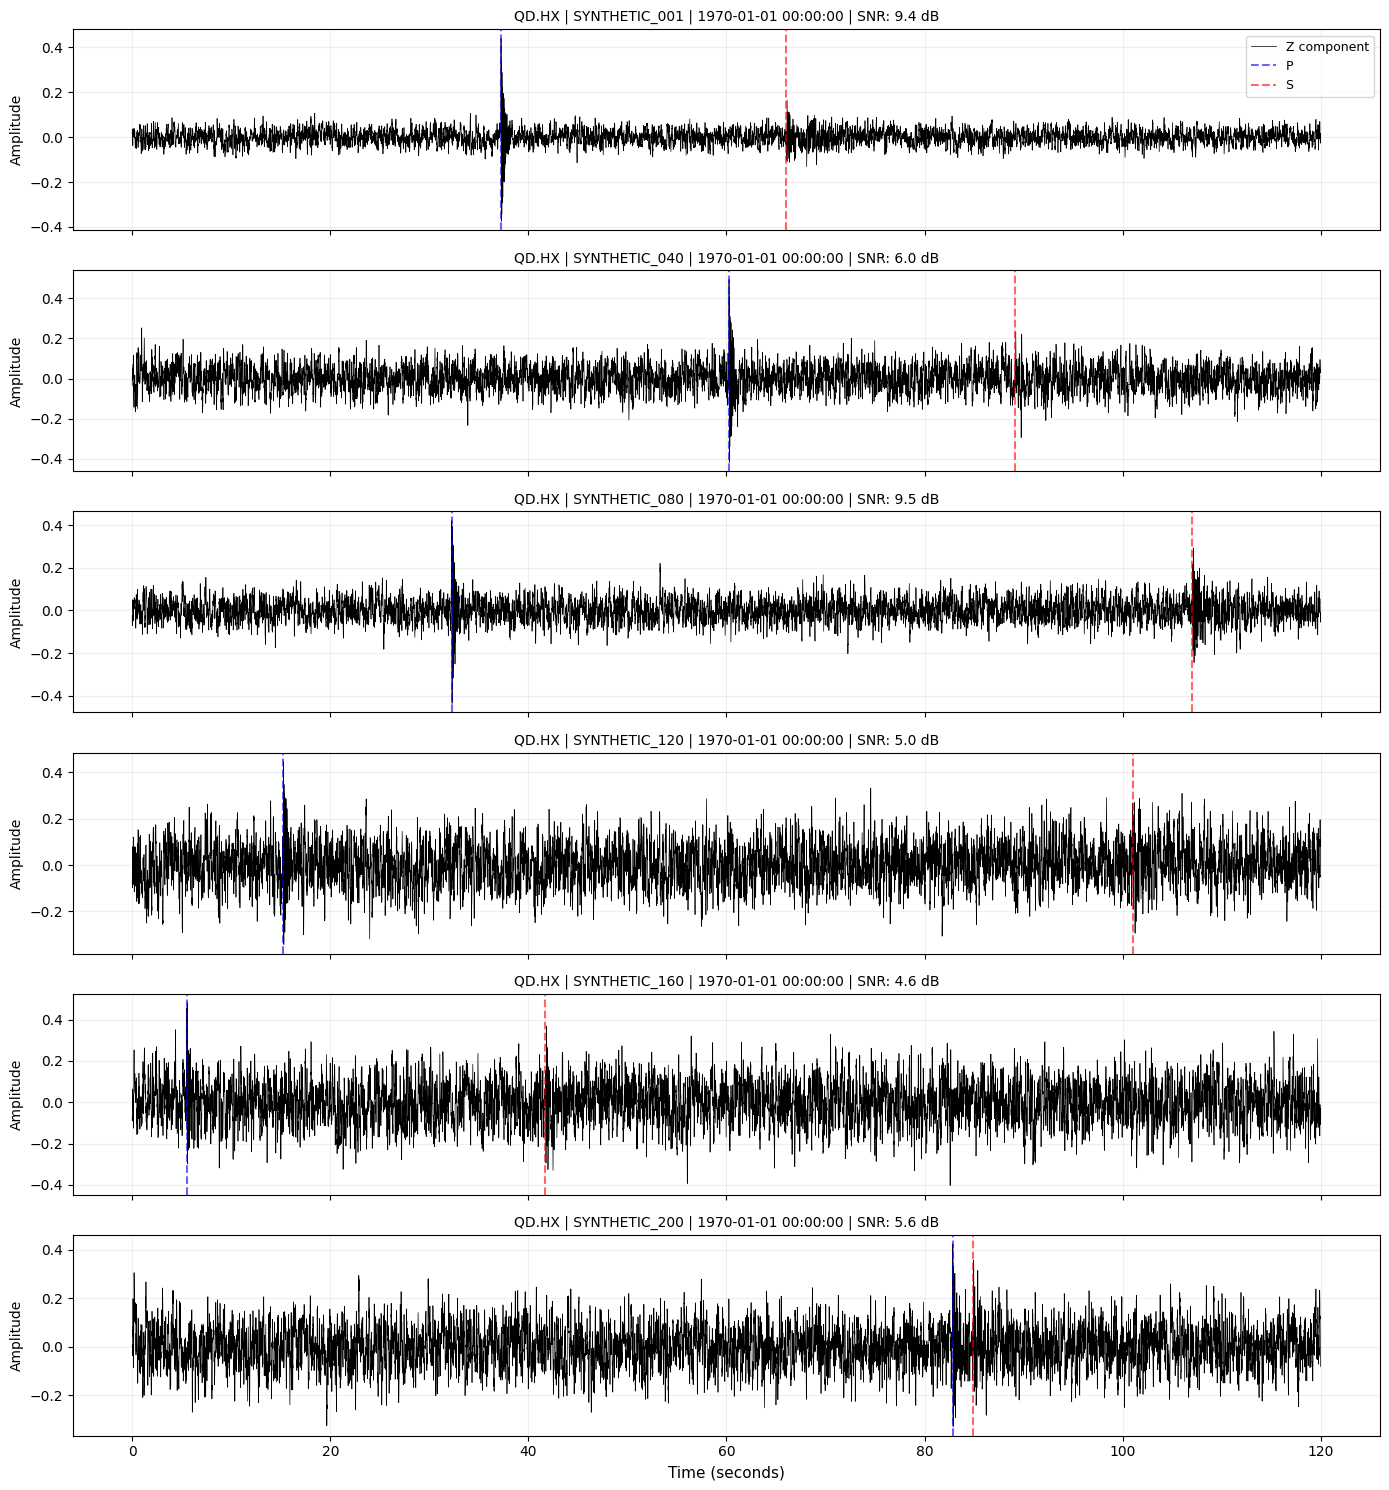

In [26]:
# Select 6 traces to display
n_display = min(6, len(dataset))
indices = np.linspace(0, len(dataset)-1, n_display, dtype=int)

fig, axes = plt.subplots(n_display, 1, figsize=(14, 2.5*n_display), sharex=True)
if n_display == 1:
    axes = [axes]

for idx, ax in zip(indices, axes):
    waveform = dataset.get_waveforms(idx)
    meta = dataset.metadata.iloc[idx]
    
    # Extract station and timing information
    network = meta['station_network_code']
    station = meta['station_code']
    event_id = meta['source_id']
    
    # Get datetime if available
    if 'trace_start_time' in meta and pd.notna(meta['trace_start_time']):
        start_time = pd.to_datetime(meta['trace_start_time'])
        datetime_str = start_time.strftime('%Y-%m-%d %H:%M:%S')
    else:
        datetime_str = 'N/A'
    
    # Plot Z component only for overview
    time = np.arange(waveform.shape[1]) / meta['trace_sampling_rate_hz']
    ax.plot(time, waveform[0], 'k-', linewidth=0.5, label='Z component')
    
    # Mark picks
    if not np.isnan(meta['trace_p_arrival_sample']):
        ax.axvline(meta['trace_p_arrival_sample'] / meta['trace_sampling_rate_hz'], 
                  color='blue', linestyle='--', alpha=0.6, label='P')
    if not np.isnan(meta['trace_s_arrival_sample']):
        ax.axvline(meta['trace_s_arrival_sample'] / meta['trace_sampling_rate_hz'], 
                  color='red', linestyle='--', alpha=0.6, label='S')
    
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f"{network}.{station} | {event_id} | {datetime_str} | SNR: {meta['trace_snr_db']:.1f} dB", 
                fontsize=10)
    ax.grid(True, alpha=0.2)
    if idx == indices[0]:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()


## 7. Filter Dataset by SNR

Demonstrate filtering to select only high-quality traces.

In [27]:
# Create a filter mask for high SNR traces (> 6 dB)
high_snr_mask = dataset.metadata['trace_snr_db'] > 6.0

print(f"Original dataset: {len(dataset)} traces")
print(f"High SNR traces (>6 dB): {high_snr_mask.sum()} traces")

# Create filtered dataset (returns a copy)
high_snr_dataset = dataset.filter(high_snr_mask, inplace=False)

print(f"\nFiltered dataset: {len(high_snr_dataset)} traces")
print(f"SNR range in filtered data: {high_snr_dataset.metadata['trace_snr_db'].min():.2f} - {high_snr_dataset.metadata['trace_snr_db'].max():.2f} dB")

Original dataset: 200 traces
High SNR traces (>6 dB): 106 traces

Filtered dataset: 106 traces
SNR range in filtered data: 6.04 - 9.99 dB


## 8. Direct Access to HDF5 and CSV

You can also directly read the files without using SeisBench, though using SeisBench is recommended.

In [28]:
import h5py

# Read CSV directly with pandas
df = pd.read_csv('../data/metadata.csv')
print("CSV Metadata:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"\nFirst row:")
print(df.iloc[0])

CSV Metadata:
  Shape: (200, 24)
  Columns: 24

First row:
trace_name_original        QD.HX.HHE.HHN.HHZ.1970-01-01T0000001970-01-01T...
station_network_code                                                      QD
station_code                                                              HX
station_latitude_deg                                                 34.7763
station_longitude_deg                                               -98.6475
trace_channel                                                             HH
trace_sampling_rate_hz                                                 100.0
trace_npts                                                             12000
trace_start_time                                         1970-01-01T00:00:00
trace_p_arrival_sample                                                  3723
trace_p_status                                                        manual
trace_p_weight                                                           1.0
trace_s_arrival_s

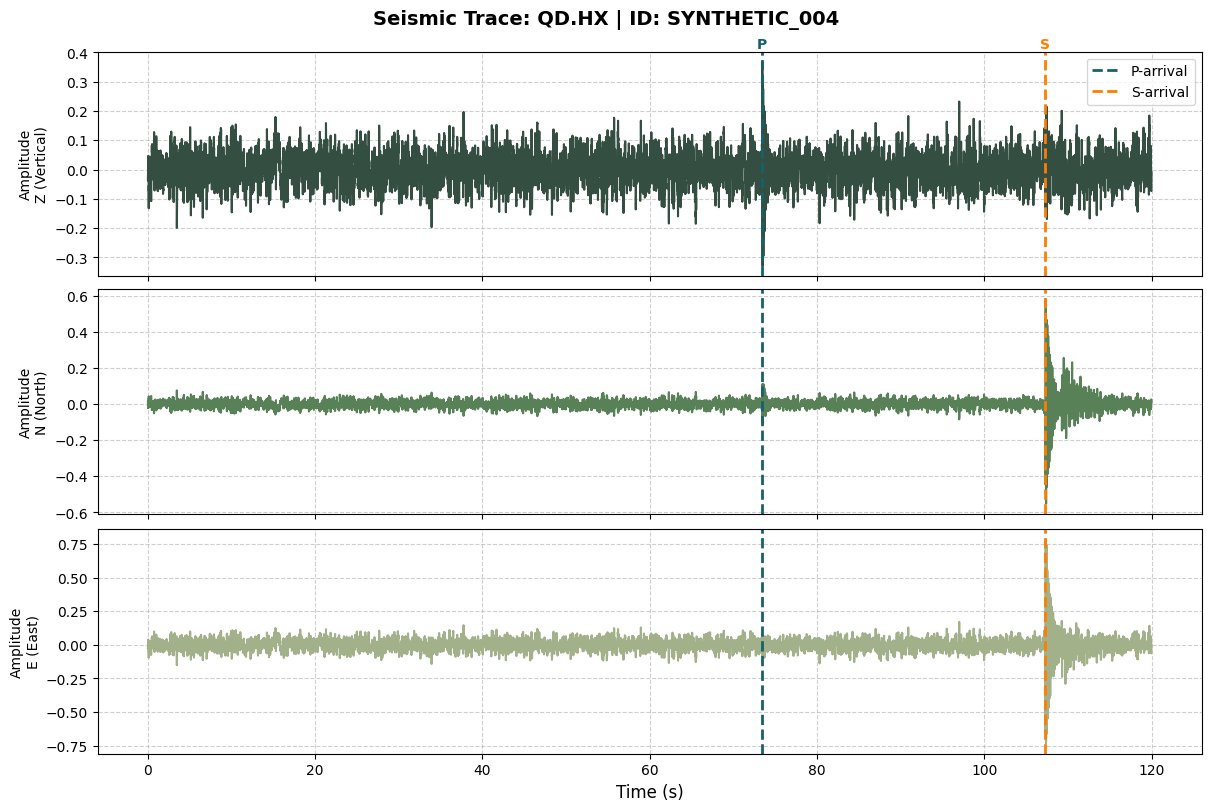

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select trace index
trace_idx = 3

# Get waveforms and metadata
waveforms = dataset.get_waveforms(trace_idx)
metadata = dataset.metadata.iloc[trace_idx]

# Extract parameters
sampling_rate = metadata["trace_sampling_rate_hz"]
n_samples = waveforms.shape[1]
time = np.arange(n_samples) / sampling_rate
net_sta = f"{metadata['station_network_code']}.{metadata['station_code']}"

# Setup plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
components = ["Z (Vertical)", "N (North)", "E (East)"]

# Color scheme from user request
# waveform_colors for Z, N, E roughly matching the gradient in the example
# The example had E, N, Z order for plotting, here we have Z, N, E.
# Let's assign: Z -> #344e41 (Darkest), N -> #588157, E -> #a3b18a (Lightest)
colors = ['#344e41', '#588157', '#a3b18a'] 

for i, (ax, comp, color) in enumerate(zip(axes, components, colors)):
    # Plot waveform
    ax.plot(time, waveforms[i], color=color, linewidth=1.5)
    
    # Add labels and grid
    ax.set_ylabel(f"Amplitude\n{comp}", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Plot phase picks if available
    if "trace_p_arrival_sample" in metadata and not np.isnan(metadata["trace_p_arrival_sample"]):
        p_time = metadata["trace_p_arrival_sample"] / sampling_rate
        # Using label_colors[0] (#15616d - teal) for P-arrival to match snippet style
        ax.axvline(p_time, color='#15616d', linestyle='--', linewidth=2, label="P-arrival" if i == 0 else "")
        if i == 0: 
            ax.text(p_time, ax.get_ylim()[1], "P", color='#15616d', ha="center", va="bottom", fontweight="bold")

    if "trace_s_arrival_sample" in metadata and not np.isnan(metadata["trace_s_arrival_sample"]):
        s_time = metadata["trace_s_arrival_sample"] / sampling_rate
        # Using label_colors[1] (#ff7d00 - orange) for S-arrival
        ax.axvline(s_time, color='#ff7d00', linestyle='--', linewidth=2, label="S-arrival" if i == 0 else "")
        if i == 0:
            ax.text(s_time, ax.get_ylim()[1], "S", color='#ff7d00', ha="center", va="bottom", fontweight="bold")
            
    # Remove x-axis tick labels for top plots
    if i < 2:
        plt.setp(ax.get_xticklabels(), visible=False)

# Add Legend to the first plot
if axes[0].get_legend_handles_labels()[1]:
    axes[0].legend(loc="upper right", fontsize=10)

axes[-1].set_xlabel("Time (s)", fontsize=12)
fig.suptitle(f"Seismic Trace: {net_sta} | ID: {metadata['source_id']}", fontsize=14, fontweight="bold")

plt.show()

In [30]:
# Load the synthetic dataset
dataset = sbd.WaveformDataset('../data', sampling_rate=100)
print("Dataset loaded successfully!")

2026-02-17 15:53:32,670 | seisbench | WARNING | Component order not specified, defaulting to 'ZNE'.


Dataset loaded successfully!


In [31]:
train = dataset.train()
dev = dataset.dev()
test = dataset.test()

In [32]:
print("Train:", train)
print("Dev:", dev)
print("Test:", test)

Train: Unnamed dataset - 140 traces
Dev: Unnamed dataset - 30 traces
Test: Unnamed dataset - 30 traces


In [33]:
# Read HDF5 directly
with h5py.File('../data/waveforms.hdf5', 'r') as f:
    print("HDF5 Structure:")
    print(f"  Keys: {list(f.keys())}")
    
    # Check data_format
    if 'data_format' in f:
        print(f"\n  Data format attributes:")
        for key, value in f['data_format'].attrs.items():
            print(f"    {key}: {value}")
    
    # Access trace data (stored in bucket0)
    if 'bucket0' in f:
        bucket = f['bucket0']
        print(f"\n  Bucket0 shape: {bucket.shape}")
        print(f"  Bucket0 dtype: {bucket.dtype}")
        
        # Read first trace
        first_trace = bucket[0, :, :]
        print(f"\n  First trace shape: {first_trace.shape}")
        print(f"  Components × Samples: {first_trace.shape[0]} × {first_trace.shape[1]}")

HDF5 Structure:
  Keys: ['data', 'data_format']

  Data format attributes:


## 9. Summary

This notebook demonstrated:
- ✅ Loading a SeisBench dataset from disk
- ✅ Inspecting metadata with pandas
- ✅ Accessing waveform data
- ✅ Visualizing 3-component seismograms with phase picks
- ✅ Batch loading multiple traces
- ✅ Filtering datasets by criteria
- ✅ Direct access to CSV and HDF5 files

The synthetic dataset is now ready for use with SeisBench models like PhaseNet and EQTransformer!